# Master Test Notebook — Planner, Database, Analytics

One notebook, run top to bottom. Covers:
1. Core planner logic (bmr_tdee, diet_logic, workout_logic)
2. Database layer (connection, insert, fetch, constraints)
3. Analytics functions + adherence-vs-weight correlation

**Before running:** confirm `.env` is correct, tables exist (`sql/create_tables.sql` has been run), and seed data is imported. Set `DEMO_USER_ID` in the Analytics section to your actual seeded user's ID.

**Habit:** Restart Kernel → Run All before trusting results — don't rely on out-of-order cell execution.

In [10]:
import sys
sys.path.append('.')

import pandas as pd
from datetime import date, timedelta
from scipy import stats

from modules.bmr_tdee import calculate_bmr, calculate_tdee, calculate_bmi
from modules.diet_logic import get_diet_plan
from modules.workout_logic import get_workout_split
from modules.database import (
    get_connection, insert_user, insert_daily_log, get_user_by_id, get_logs_for_user
)
from modules.analytics import get_weekly_adherence, get_rolling_weight_trend, get_weekly_activity

---
# PART 1 — Core Planner Logic

## 1.1 BMR / TDEE / BMI — normal cases

Check at least one of these against a trusted online TDEE calculator.

In [11]:
test_users = [
    {"weight_kg": 70, "height_cm": 170, "age": 25, "gender": "male", "activity_level": "moderately_active"},
    {"weight_kg": 58, "height_cm": 160, "age": 22, "gender": "female", "activity_level": "lightly_active"},
    {"weight_kg": 85, "height_cm": 180, "age": 30, "gender": "male", "activity_level": "very_active"},
]

for user in test_users:
    bmr = calculate_bmr(user["weight_kg"], user["height_cm"], user["age"], user["gender"])
    tdee = calculate_tdee(bmr, user["activity_level"])
    bmi = calculate_bmi(user["weight_kg"], user["height_cm"])
    print(f"{user}")
    print(f"  BMR: {bmr:.1f} kcal | TDEE: {tdee:.1f} kcal | BMI: {bmi:.1f}\n")

{'weight_kg': 70, 'height_cm': 170, 'age': 25, 'gender': 'male', 'activity_level': 'moderately_active'}
  BMR: 1642.5 kcal | TDEE: 2545.9 kcal | BMI: 24.2

{'weight_kg': 58, 'height_cm': 160, 'age': 22, 'gender': 'female', 'activity_level': 'lightly_active'}
  BMR: 1309.0 kcal | TDEE: 1799.9 kcal | BMI: 22.7

{'weight_kg': 85, 'height_cm': 180, 'age': 30, 'gender': 'male', 'activity_level': 'very_active'}
  BMR: 1830.0 kcal | TDEE: 3156.8 kcal | BMI: 26.2



## 1.2 BMR / TDEE — edge cases (should raise ValueError)

In [12]:
print(calculate_bmr(70, 170, 25, "Male "))  # normalized casing/whitespace should still work

try:
    calculate_bmr(70, 170, 25, "banana")
    print("FAILED: should have raised ValueError")
except ValueError as e:
    print(f"OK — correctly raised: {e}")

try:
    calculate_tdee(1600, "lightly active")  # space instead of underscore, should normalize
    print("OK — normalized space to underscore")
except ValueError as e:
    print(f"FAILED unexpectedly: {e}")

try:
    calculate_tdee(1600, "super_active")  # not a real key
    print("FAILED: should have raised ValueError")
except ValueError as e:
    print(f"OK — correctly raised: {e}")

1642.5
OK — correctly raised: Invalid gender: 'banana'. Expected 'male' or 'female'.
OK — normalized space to underscore
OK — correctly raised: Invalid activity level: 'super_active'. Expected one of ['sedentary', 'lightly_active', 'moderately_active', 'very_active', 'extra_active'].


## 1.3 Diet plan — all three goals

Manually check: does protein_g×4 + carbs_g×4 + fat_g×9 land close to calorie_target?

In [13]:
sample_tdee = 2200

for goal in ["muscle_gain", "fat_loss", "maintenance"]:
    plan = get_diet_plan(sample_tdee, goal)
    check = plan["protein_g"] * 4 + plan["carbs_g"] * 4 + plan["fat_g"] * 9
    print(f"Goal: {goal}")
    print(f"  {plan}")
    print(f"  Reconstructed calories: {check:.0f} (target was {plan['calorie_target']})\n")

Goal: muscle_gain
  {'calorie_target': 2500, 'protein_g': 187.5, 'carbs_g': 281.2, 'fat_g': 69.4}
  Reconstructed calories: 2499 (target was 2500)

Goal: fat_loss
  {'calorie_target': 1700, 'protein_g': 170.0, 'carbs_g': 127.5, 'fat_g': 56.7}
  Reconstructed calories: 1700 (target was 1700)

Goal: maintenance
  {'calorie_target': 2200, 'protein_g': 165.0, 'carbs_g': 220.0, 'fat_g': 73.3}
  Reconstructed calories: 2200 (target was 2200)



## 1.4 Workout split — check logic across goal x experience combos

In [14]:
combos = [
    ("muscle_gain", "advanced"),
    ("fat_loss", "beginner"),
    ("maintenance", "intermediate"),
]

for goal, level in combos:
    print(f"=== Goal: {goal} | Experience: {level} ===")
    split = get_workout_split(goal, level)
    for day, details in split.items():
        if details["type"] == "rest":
            print(f"  {day}: Rest")
        else:
            print(f"  {day}: {details['type']} — {details['sets']}x{details['reps']}, rest {details['rest_seconds']}s")
    print()

=== Goal: muscle_gain | Experience: advanced ===
  Monday: push — 4x8-12, rest 90s
  Tuesday: pull — 4x8-12, rest 90s
  Wednesday: legs — 4x8-12, rest 90s
  Thursday: Rest
  Friday: push — 4x8-12, rest 90s
  Saturday: pull — 4x8-12, rest 90s
  Sunday: legs — 4x8-12, rest 90s

=== Goal: fat_loss | Experience: beginner ===
  Monday: full_body — 3x12-15, rest 45s
  Tuesday: Rest
  Wednesday: full_body — 3x12-15, rest 45s
  Thursday: Rest
  Friday: full_body — 3x12-15, rest 45s
  Saturday: Rest
  Sunday: Rest

=== Goal: maintenance | Experience: intermediate ===
  Monday: upper — 3x8-12, rest 60s
  Tuesday: lower — 3x8-12, rest 60s
  Wednesday: Rest
  Thursday: upper — 3x8-12, rest 60s
  Friday: lower — 3x8-12, rest 60s
  Saturday: Rest
  Sunday: Rest



## 1.5 Full end-to-end — one simulated user through all three planner modules

In [15]:
sim_user = {
    "weight_kg": 65, "height_cm": 165, "age": 24, "gender": "female",
    "activity_level": "moderately_active", "goal": "fat_loss", "experience_level": "beginner"
}

bmr = calculate_bmr(sim_user["weight_kg"], sim_user["height_cm"], sim_user["age"], sim_user["gender"])
tdee = calculate_tdee(bmr, sim_user["activity_level"])
diet_plan = get_diet_plan(tdee, sim_user["goal"])
workout_split = get_workout_split(sim_user["goal"], sim_user["experience_level"])

print(f"BMR: {bmr:.1f} | TDEE: {tdee:.1f}\n")
print(f"Diet plan: {diet_plan}\n")
print("Workout split:")
for day, details in workout_split.items():
    print(f"  {day}: {details['type']}")

BMR: 1400.2 | TDEE: 2170.4

Diet plan: {'calorie_target': 1670, 'protein_g': 167.0, 'carbs_g': 125.3, 'fat_g': 55.7}

Workout split:
  Monday: full_body
  Tuesday: rest
  Wednesday: full_body
  Thursday: rest
  Friday: full_body
  Saturday: rest
  Sunday: rest


---
# PART 2 — Database Layer

## 2.1 Test the raw connection

If this fails, fix it before running the rest of Part 2.

In [16]:
try:
    conn = get_connection()
    print("Connection successful:", conn.is_connected())
    conn.close()
except ConnectionError as e:
    print(f"Connection FAILED: {e}")
    print("Check .env — DB_HOST, DB_PORT, DB_USER, DB_PASSWORD, DB_NAME")

Connection successful: True


## 2.2 Insert a test user, fetch it back

In [17]:
test_user_id = insert_user(
    name="Test User", age=25, gender="female", height_cm=165, weight_kg=60,
    activity_level="moderately_active", goal="fat_loss", dietary_pref="vegetarian"
)
print(f"Inserted user with user_id: {test_user_id}")

fetched_user = get_user_by_id(test_user_id)
print(f"Fetched back: {fetched_user}")

assert fetched_user is not None, "FAILED: user not found after insert"
assert fetched_user["name"] == "Test User", "FAILED: name mismatch"
assert fetched_user["goal"] == "fat_loss", "FAILED: goal mismatch"
print("\nAll checks passed.")

Inserted user with user_id: 4
Fetched back: {'user_id': 4, 'name': 'Test User', 'age': 25, 'gender': 'female', 'height_cm': Decimal('165.00'), 'weight_kg': Decimal('60.00'), 'activity_level': 'moderately_active', 'goal': 'fat_loss', 'dietary_pref': 'vegetarian', 'created_at': datetime.datetime(2026, 8, 30, 0, 33, 42)}

All checks passed.


# Test forecasting.py

Fits Prophet on the seeded demo user's weight history and checks the output makes sense.

**Before running:** set `DEMO_USER_ID` below, and make sure `prophet` is installed (`pip install prophet` — it's a slow install, already in your requirements.txt from Phase 0).

In [18]:
import sys
sys.path.append('.')

from modules.forecasting import prepare_prophet_input, fit_and_forecast, generate_forecast_chart, get_forecast_summary

DEMO_USER_ID = 1  # demo user's ID

## 1. Check the input shape before fitting anything

Confirms `ds`/`y` columns exist and dates look right — catch a data problem here, not three cells later inside Prophet's error output.

In [19]:
prophet_input = prepare_prophet_input(DEMO_USER_ID)
print(f"{len(prophet_input)} rows of history")
print(prophet_input.head())
print(prophet_input.dtypes)

200 rows of history
          ds     y
0 2025-01-01  71.5
1 2025-01-02  69.6
2 2025-01-03  71.9
3 2025-01-04  74.6
4 2025-01-05  69.3
ds    datetime64[s]
y           float64
dtype: object


c:\Users\Divya\Documents\workout_planner\modules\analytics.py:84: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))


## 2. Fit the model and forecast

This will print Prophet's own fitting log (informational, not an error) — that's normal.

In [20]:
model, forecast = fit_and_forecast(DEMO_USER_ID, periods_days=28)

print(f"Forecast dataframe shape: {forecast.shape}")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

c:\Users\Divya\Documents\workout_planner\modules\analytics.py:84: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))
00:33:42 - cmdstanpy - INFO - Chain [1] start processing
00:33:43 - cmdstanpy - INFO - Chain [1] done processing


Forecast dataframe shape: (228, 16)
            ds       yhat  yhat_lower  yhat_upper
218 2025-08-07  70.912116   67.413643   74.046489
219 2025-08-08  69.868201   66.206289   73.388476
220 2025-08-09  70.713989   67.153408   73.959505
221 2025-08-10  69.673562   66.474518   73.230968
222 2025-08-11  70.706679   67.176808   74.256843
223 2025-08-12  70.600316   67.138161   74.027641
224 2025-08-13  69.559655   66.007355   73.048388
225 2025-08-14  70.936490   67.460167   74.524215
226 2025-08-15  69.892574   66.289360   73.450089
227 2025-08-16  70.738362   67.130895   74.174432


## 3. Sanity checks

Basic assertions — not exhaustive, but catches obviously broken output (e.g. a forecast that's flat-zero or wildly diverging).

In [21]:
assert forecast['yhat'].notna().all(), "FAILED: forecast contains null predictions"
assert (forecast['yhat_upper'] >= forecast['yhat_lower']).all(), "FAILED: confidence bounds inverted"

# Weight forecasts should stay in a plausible human range — catches unit
# errors or a badly malformed input more reliably than checking exact values.
assert forecast['yhat'].between(20, 300).all(), "FAILED: forecasted weight outside plausible human range"

print("All sanity checks passed.")

All sanity checks passed.


## 4. Plot history + forecast + confidence band

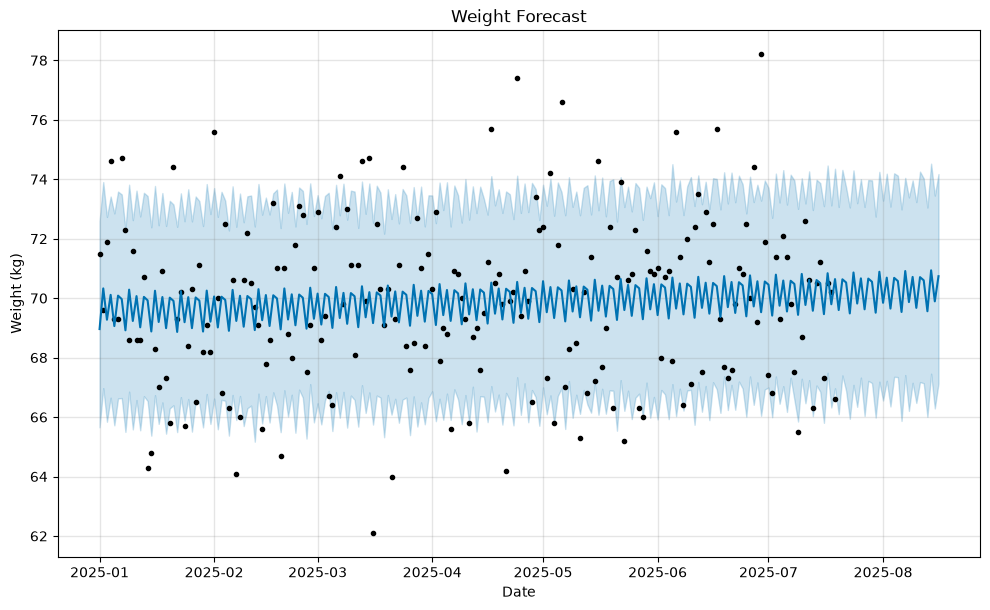

In [22]:
fig = generate_forecast_chart(model, forecast)

## 5. Look at the trend/seasonality decomposition

This is worth actually looking at, not skipping — it's the part of Prophet
that explains WHY it's forecasting what it's forecasting (separate trend vs.
weekly pattern), which you'll want to understand if asked about this in a
review.

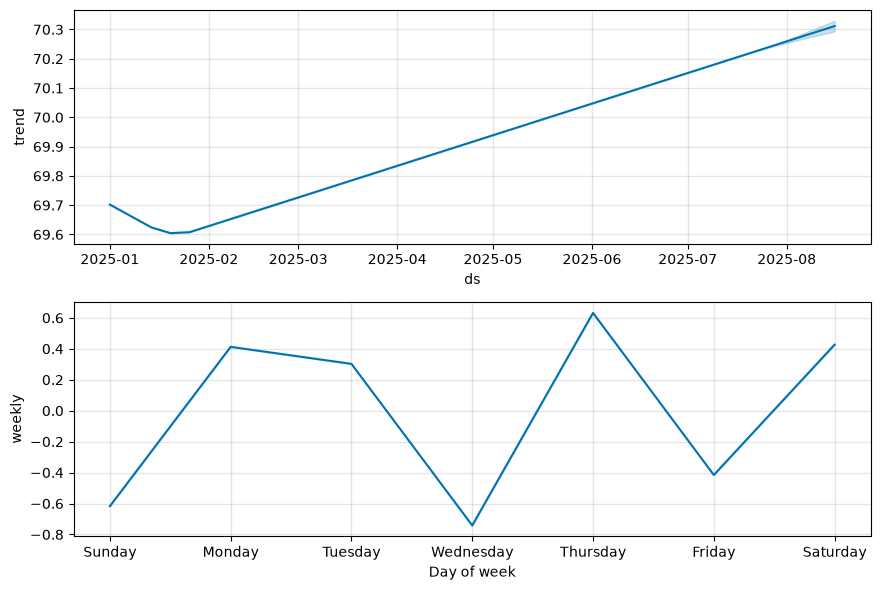

In [23]:
fig2 = model.plot_components(forecast)

## 6. Human-readable summary

In [24]:
print(get_forecast_summary(forecast))

# Optionally, with a target weight:
# print(get_forecast_summary(forecast, target_weight=65))

At your current trend, your projected weight around August 16, 2025 is approximately 70.7 kg (range: 67.1–74.2 kg).


## 7. Notes for your README

Fill in after looking at the plots above:

- Does the weekly seasonality component show anything interesting (e.g. weekend vs weekday pattern)?
- How wide is the confidence interval by day 28? A very wide band is honest uncertainty, not a bug — worth explaining rather than hiding.
- Known limitation to state explicitly: Prophet has no idea this data is partly synthetic, and it doesn't know about deliberate future changes (new diet plan, injury, etc.) — it only extrapolates from the pattern it's already seen.

In [25]:
# Your notes here

## 2.3 Insert a week of daily logs

In [26]:
start_date = date.today() - timedelta(days=6)
starting_weight = 60.0

for i in range(7):
    log_date = start_date + timedelta(days=i)
    weight = starting_weight - (i * 0.1)
    log_id = insert_daily_log(
        user_id=test_user_id, log_date=log_date, weight_kg=round(weight, 1),
        calories_consumed=1800 + (i * 10), protein_g=120, carbs_g=150, fat_g=55,
        workout_completed=(i % 2 == 0), steps_walked=7000 + (i * 200),
        notes=f"Day {i+1} test log"
    )
    print(f"Inserted log_id {log_id} for {log_date}, weight {weight:.1f}kg")

Inserted log_id 209 for 2026-08-24, weight 60.0kg
Inserted log_id 210 for 2026-08-25, weight 59.9kg
Inserted log_id 211 for 2026-08-26, weight 59.8kg
Inserted log_id 212 for 2026-08-27, weight 59.7kg
Inserted log_id 213 for 2026-08-28, weight 59.6kg
Inserted log_id 214 for 2026-08-29, weight 59.5kg
Inserted log_id 215 for 2026-08-30, weight 59.4kg


## 2.4 Fetch logs back, check ordering

In [27]:
fetched_logs = get_logs_for_user(test_user_id)
print(f"Fetched {len(fetched_logs)} logs (expected 7)")

assert len(fetched_logs) == 7, f"FAILED: expected 7 logs, got {len(fetched_logs)}"
assert fetched_logs[0]['log_date'] > fetched_logs[-1]['log_date'], "FAILED: not ordered most-recent-first"
print("All checks passed.")

Fetched 7 logs (expected 7)
All checks passed.


## 2.5 Test the `limit` parameter

In [28]:
recent_3 = get_logs_for_user(test_user_id, limit=3)
assert len(recent_3) == 3, f"FAILED: expected 3, got {len(recent_3)}"
print("OK")

OK


## 2.6 Test the unique_user_date constraint

Should raise — this confirms the schema constraint is actually enforced.

In [29]:
try:
    insert_daily_log(user_id=test_user_id, log_date=start_date, weight_kg=59.9)
    print("FAILED: duplicate insert should have raised an error")
except Exception as e:
    print(f"OK — correctly rejected duplicate: {type(e).__name__}: {e}")

OK — correctly rejected duplicate: IntegrityError: 1062 (23000): Duplicate entry '4-2026-08-24' for key 'daily_logs.unique_user_date'


## 2.7 Cleanup — deletes the test user (cascades to their logs)

Run this before moving on, or re-running Part 2 later will hit the unique_user_date constraint on old leftover data.

In [30]:
conn = get_connection()
cursor = conn.cursor()
cursor.execute("DELETE FROM users WHERE user_id = %s", (test_user_id,))
conn.commit()

remaining_logs = get_logs_for_user(test_user_id)
assert len(remaining_logs) == 0, "FAILED: cascade delete did not remove logs"
print(f"Deleted test user {test_user_id}, cascade delete confirmed working.")

cursor.close()
conn.close()

Deleted test user 4, cascade delete confirmed working.


---
# PART 3 — Analytics + Correlation

Uses your real seeded demo user (from `import_seed_data.py`), not the throwaway test user above.

In [31]:
DEMO_USER_ID = 1  # <-- change this to your actual seeded demo user's user_id

## 3.1 Sanity-check each analytics function

In [32]:
adherence_df = get_weekly_adherence(DEMO_USER_ID)
print(f"Weekly adherence — {len(adherence_df)} weeks:")
print(adherence_df)
assert not adherence_df.empty, "FAILED: no adherence data — check DEMO_USER_ID"
assert adherence_df['adherence_pct'].between(0, 100).all(), "FAILED: adherence_pct out of 0-100 range"

Weekly adherence — 29 weeks:
      week  days_logged  workouts_completed  adherence_pct
0   202452            4                 4.0          100.0
1   202501            7                 7.0          100.0
2   202502            7                 7.0          100.0
3   202503            7                 7.0          100.0
4   202504            7                 7.0          100.0
5   202505            7                 7.0          100.0
6   202506            7                 7.0          100.0
7   202507            7                 7.0          100.0
8   202508            7                 7.0          100.0
9   202509            7                 7.0          100.0
10  202510            7                 7.0          100.0
11  202511            7                 7.0          100.0
12  202512            7                 7.0          100.0
13  202513            7                 7.0          100.0
14  202514            7                 7.0          100.0
15  202515            7    

c:\Users\Divya\Documents\workout_planner\modules\analytics.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))


In [33]:
rolling_df = get_rolling_weight_trend(DEMO_USER_ID)
print(f"Rolling weight trend — {len(rolling_df)} days:")
print(rolling_df.head(10))
assert not rolling_df.empty, "FAILED: no weight trend data"
assert rolling_df['rolling_7day_avg'].notna().any(), "FAILED: rolling average is all null"

Rolling weight trend — 200 days:
     log_date  weight_kg  rolling_7day_avg
0  2025-01-01       71.5             71.50
1  2025-01-02       69.6             70.55
2  2025-01-03       71.9             71.00
3  2025-01-04       74.6             71.90
4  2025-01-05       69.3             71.38
5  2025-01-06       69.3             71.03
6  2025-01-07       74.7             71.56
7  2025-01-08       72.3             71.67
8  2025-01-09       68.6             71.53
9  2025-01-10       71.6             71.49


c:\Users\Divya\Documents\workout_planner\modules\analytics.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))


In [34]:
activity_df = get_weekly_activity(DEMO_USER_ID)
print(f"Weekly activity — {len(activity_df)} weeks:")
print(activity_df)
assert not activity_df.empty, "FAILED: no activity data"
print("\nAll three analytics functions returned sensible data.")

Weekly activity — 29 weeks:
      week  total_steps  avg_calories
0   202452      23341.0        2984.0
1   202501      51059.0        2689.0
2   202502      87689.0        2501.0
3   202503      55539.0        2278.0
4   202504      50218.0        2674.0
5   202505      59474.0        2608.0
6   202506      58919.0        2616.0
7   202507      51295.0        2826.0
8   202508      48071.0        2639.0
9   202509      61348.0        2509.0
10  202510      60286.0        2698.0
11  202511      36909.0        2837.0
12  202512      66676.0        2907.0
13  202513      67621.0        2860.0
14  202514      75355.0        2846.0
15  202515      59358.0        2572.0
16  202516      49863.0        2929.0
17  202517      68159.0        2631.0
18  202518      63026.0        2451.0
19  202519      40909.0        2573.0
20  202520      50484.0        2905.0
21  202521      61174.0        2557.0
22  202522      59861.0        2696.0
23  202523      68767.0        2997.0
24  202524      65725.

c:\Users\Divya\Documents\workout_planner\modules\analytics.py:68: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, connection, params=(user_id,))


## 3.2 Quick visual check — rolling weight trend

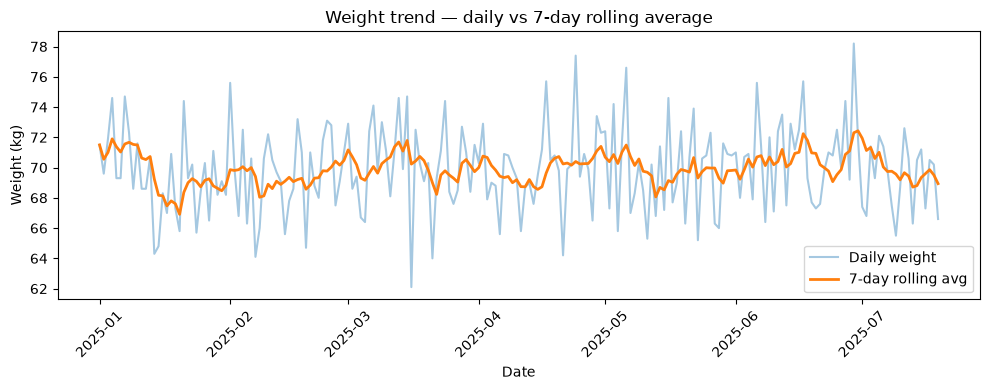

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rolling_df['log_date'], rolling_df['weight_kg'], label='Daily weight', alpha=0.4)
ax.plot(rolling_df['log_date'], rolling_df['rolling_7day_avg'], label='7-day rolling avg', linewidth=2)
ax.set_xlabel('Date')
ax.set_ylabel('Weight (kg)')
ax.set_title('Weight trend — daily vs 7-day rolling average')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.3 Build the adherence-vs-weight-change dataset

In [36]:
rolling_df['log_date'] = pd.to_datetime(rolling_df['log_date'])
rolling_df['week'] = rolling_df['log_date'].dt.strftime('%Y%W').astype(int)

weekly_weight_change = (
    rolling_df.groupby('week')['weight_kg']
    .agg(['first', 'last'])
    .assign(weight_change=lambda d: d['last'] - d['first'])
    .reset_index()[['week', 'weight_change']]
)

merged = pd.merge(adherence_df, weekly_weight_change, on='week', how='inner')
print(f"Merged dataset — {len(merged)} weeks with both adherence and weight-change data:")
print(merged[['week', 'adherence_pct', 'weight_change']])

assert len(merged) >= 3, "Need at least 3 overlapping weeks for a meaningful correlation"

Merged dataset — 28 weeks with both adherence and weight-change data:
      week  adherence_pct  weight_change
0   202501          100.0           -0.7
1   202502          100.0           -3.4
2   202503          100.0            4.5
3   202504          100.0            3.5
4   202505          100.0            3.8
5   202506          100.0           -3.6
6   202507          100.0           -1.4
7   202508          100.0           -4.5
8   202509          100.0            3.6
9   202510          100.0           -9.0
10  202511          100.0           -1.4
11  202512          100.0           -6.0
12  202513          100.0           -5.9
13  202514          100.0           -1.9
14  202515          100.0            2.2
15  202516          100.0            5.7
16  202517          100.0           -0.7
17  202518          100.0           -6.5
18  202519          100.0           -1.2
19  202520          100.0           -1.6
20  202521          100.0           -1.3
21  202522          100.0   

## 3.4 Run the correlation

Negative correlation = higher adherence weeks tend toward more weight loss (expected direction for a fat_loss-goal user).

In [37]:
correlation, p_value = stats.pearsonr(merged['adherence_pct'], merged['weight_change'])

print(f"Pearson correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

significance = "statistically significant (p < 0.05)" if p_value < 0.05 else \
    "NOT statistically significant (p >= 0.05) — likely due to small sample size"
print(f"\nThis result is {significance}.")

Pearson correlation coefficient: nan
P-value: nan

This result is NOT statistically significant (p >= 0.05) — likely due to small sample size.


C:\Users\Divya\AppData\Local\Temp\ipykernel_928\1984602530.py:1: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(merged['adherence_pct'], merged['weight_change'])


## 3.5 Interpretation — fill this in for your README

- What direction is the correlation, and does it match expectations?
- Statistically significant given the amount of data you have?
- Correlation isn't causation — what confounds could explain the result either way?
- This is largely synthetic seed data — how much should this specific result be trusted vs. treated as a demonstration of the technique?

In [38]:
# Your interpretation notes here

---
## General notes / observations